In [10]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.1


In [5]:
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(train_df.head())

Train: (66758, 3), Test: (16690, 2)
   sample_id  label                                               text
0       6031      0  mumia w wrote on escapenumber escapenumber esc...
1      75167      1   oh my dear sir her throat is so much better t...
2      69801      1  many more are victims of other cons telemarket...
3      78124      1  hello\nbest erection drugs\nworld wide shiping...
4      39905      0  may escapenumber escapenumber home u s world p...


In [11]:
vocab_size = 20000
max_length = 200
embedding_dim = 64

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'])

X_all = pad_sequences(tokenizer.texts_to_sequences(train_df['text']), maxlen=max_length, padding='post', truncating='post')
y_all = train_df['label'].values

test_padded = pad_sequences(tokenizer.texts_to_sequences(test_df['text']), maxlen=max_length, padding='post', truncating='post')

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [12]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adamw',
              metrics=['accuracy'])

In [13]:
model.fit(X_train,
          y_train,
          epochs=10,
          validation_data=(X_val, y_val),
          batch_size=64)

Epoch 1/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9430 - loss: 0.1450 - val_accuracy: 0.9796 - val_loss: 0.0606
Epoch 2/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.9784 - loss: 0.0607 - val_accuracy: 0.9828 - val_loss: 0.0537
Epoch 3/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - accuracy: 0.9851 - loss: 0.0430 - val_accuracy: 0.9828 - val_loss: 0.0509
Epoch 4/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.9863 - loss: 0.0381 - val_accuracy: 0.9591 - val_loss: 0.1446
Epoch 5/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accuracy: 0.9902 - loss: 0.0273 - val_accuracy: 0.9850 - val_loss: 0.0512
Epoch 6/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.9903 - loss: 0.0287 - val_accuracy: 0.9835 - val_loss: 0.0548
Epoch 7/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9911 - loss: 0.0250 - val_accuracy: 0.9861 - val_loss: 0.0546
Epoch 8/10
939/939 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.9921 - loss: 0.0215 - val_

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


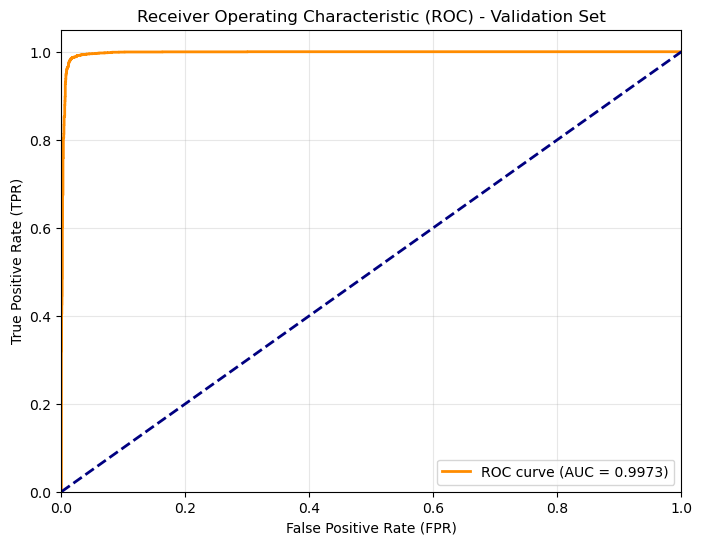

Estimated AUC: 0.9973


In [14]:
y_val_pred = model.predict(X_val).flatten()

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Validation Set')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Estimated AUC: {roc_auc:.4f}")

In [15]:
probs = model.predict(test_padded).flatten()

submission = []

for idx, row in test_df.iterrows():
    s_id = str(row['sample_id'])
    text = str(row['text'])
    
    submission.append([1, s_id, len(text)])
    submission.append([2, s_id, len(re.findall(r'\bfree\b', text.lower()))])
    submission.append([3, s_id, round(float(probs[idx]), 4)])

result_df = pd.DataFrame(submission, columns=['subtaskID', 'datapointID', 'answer'])
result_df.to_csv('submission.csv', index=False)

522/522 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step
